**Name:** V.Mariya Joevita

**Reg.No:** 3122235001077

**Ex9:** Clustering Human Activity Recognition Data using K-Means,
DBSCAN, and Hierarchical Clustering

**1. Loading dataset**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

X_test= pd.read_csv('/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset/test/X_test.txt',delim_whitespace=True, header=None)
y_test = pd.read_csv('/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset/test/y_test.txt',header = None)
X_train = pd.read_csv('/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset/train/X_train.txt',delim_whitespace=True, header=None)
y_train = pd.read_csv('/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset/train/y_train.txt',header = None)


/tmp/ipykernel_7779/1763068388.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test= pd.read_csv('/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset/test/X_test.txt',delim_whitespace=True, header=None)
/tmp/ipykernel_7779/1763068388.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv('/content/drive/MyDrive/human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset/train/X_train.txt',delim_whitespace=True, header=None)


In [3]:
X_train.head()
y_train.head()

,0
0,5
1,5
2,5
3,5
4,5


**2. Preprocessing**

In [4]:
#Checking for null values
(X_train.isnull().sum()>0).any()

#Encode categorical labels -> Already Numerical
# Check the data types of X_train columns
print("Data types in X_train:")
print(X_train.dtypes.value_counts())

# Identify non-numeric columns (if any)
non_numeric_cols = X_train.select_dtypes(include=['object', 'category']).columns

if len(non_numeric_cols) > 0:
    print(f"\nCategorical/non-numeric columns found in X_train: {list(non_numeric_cols)}")
else:
    print("\nNo categorical or non-numeric columns found in X_train. .")
#Normalization / Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)


Data types in X_train:
float64    561
Name: count, dtype: int64

No categorical or non-numeric columns found in X_train. .


**3.EDA & Feature Distribution Plots**





In [5]:
print("Training Data : input")
print(X_train.info())
print(X_train.shape)
print(X_train.describe())
print("Training Data : output")
print(y_train.info())
print(y_train.shape)
print(y_train.describe())

Training Data : input
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, 0 to 560
dtypes: float64(561)
memory usage: 31.5 MB
None
(7352, 561)
               0            1            2            3            4    \
count  7352.000000  7352.000000  7352.000000  7352.000000  7352.000000   
mean      0.274488    -0.017695    -0.109141    -0.605438    -0.510938   
std       0.070261     0.040811     0.056635     0.448734     0.502645   
min      -1.000000    -1.000000    -1.000000    -1.000000    -0.999873   
25%       0.262975    -0.024863    -0.120993    -0.992754    -0.978129   
50%       0.277193    -0.017219    -0.108676    -0.946196    -0.851897   
75%       0.288461    -0.010783    -0.097794    -0.242813    -0.034231   
max       1.000000     1.000000     1.000000     1.000000     0.916238   

               5            6            7            8            9    ...  \
count  7352.000000  7352.000000  7352.000000  7352.000000  7352.000

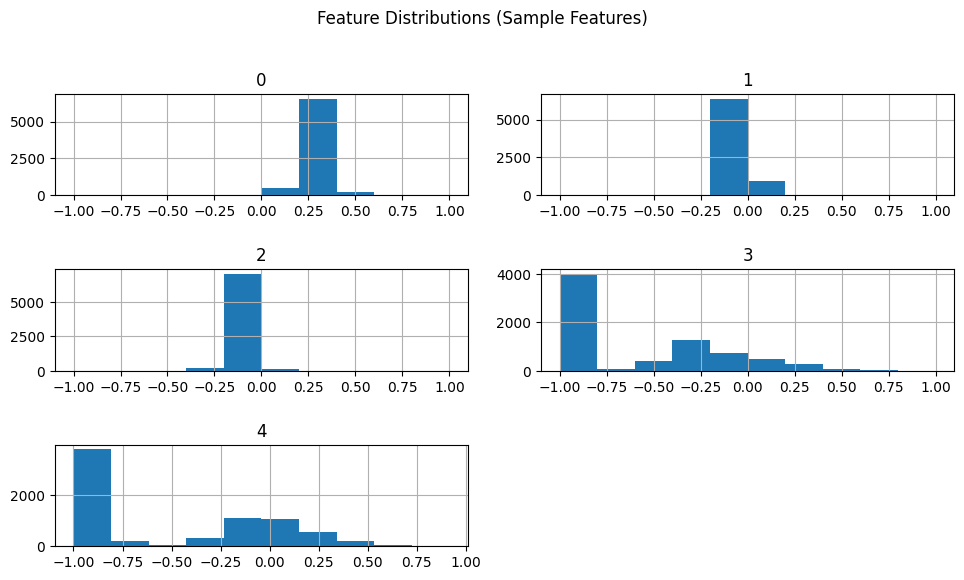

In [6]:
import matplotlib.pyplot as plt

# select first 5 features
X_train.iloc[:, :5].hist(figsize=(10,6))
plt.suptitle("Feature Distributions (Sample Features)")
plt.tight_layout(pad=2.0)
plt.show()

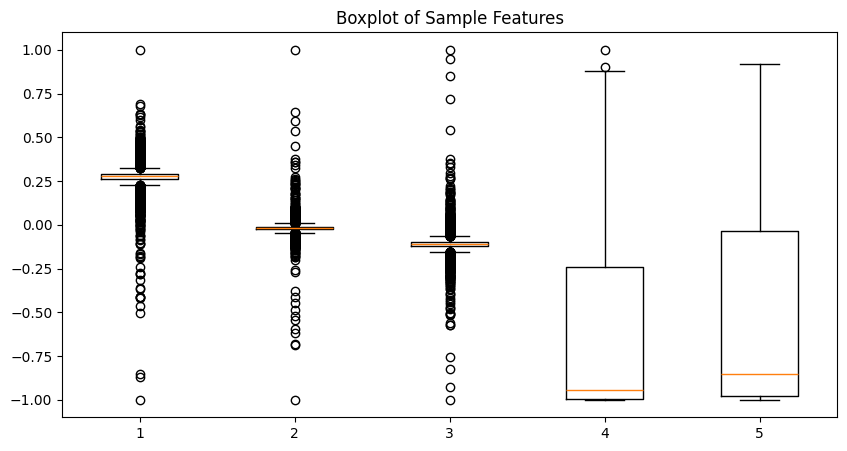

In [7]:
plt.figure(figsize=(10,5))
plt.boxplot(X_train.iloc[:, :5])
plt.title("Boxplot of Sample Features")
plt.show()

**4. Dimensionality reduction using PCA / TSNE and Visualization**

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

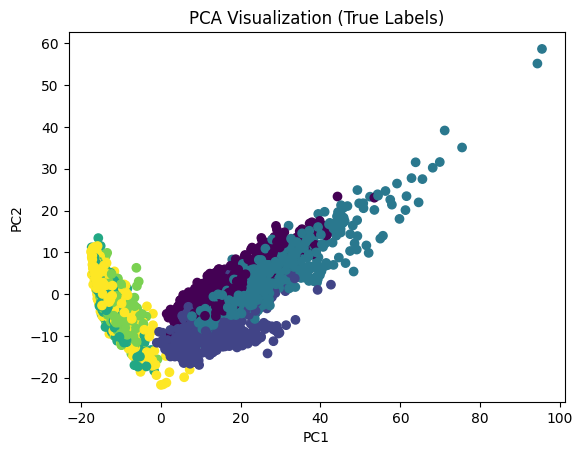

In [9]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train.values.ravel(), cmap='viridis')
plt.title("PCA Visualization (True Labels)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("Scatter_pca.png")
plt.show()

In [10]:
#TSNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled[:2000])  # use subset for speed
y_subset = y_train[:2000]

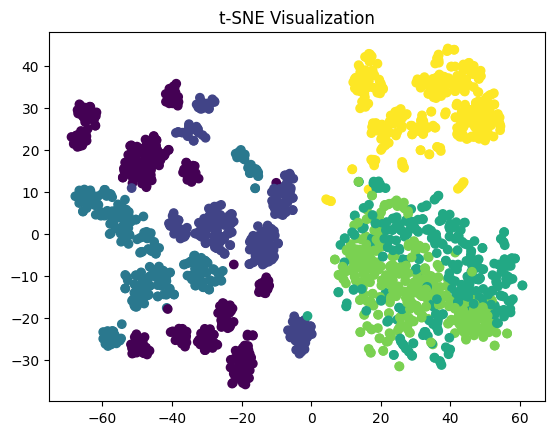

In [11]:
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_subset, cmap='viridis')
plt.title("t-SNE Visualization")
plt.savefig("Scatter_tsne.png")
plt.show()

**5. KMeans Clustering**

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

wcss = []
sil_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Print values (for table)
for i, k in enumerate(k_values):
    print(f"k={k}, WCSS={wcss[i]}, Silhouette={sil_scores[i]}")

k=2, WCSS=2336223.7520021033, Silhouette=0.39650494031412553
k=3, WCSS=2081849.6271975653, Silhouette=0.3274077920801446
k=4, WCSS=1976452.643019128, Silhouette=0.1651628752674826
k=5, WCSS=1875066.0899230486, Silhouette=0.1306386109231235
k=6, WCSS=1818790.0682136675, Silhouette=0.1086410631864108
k=7, WCSS=1776518.7291605147, Silhouette=0.11142407811150756
k=8, WCSS=1737555.4358311258, Silhouette=0.07386062149068542


**5.1 Elbow Method**

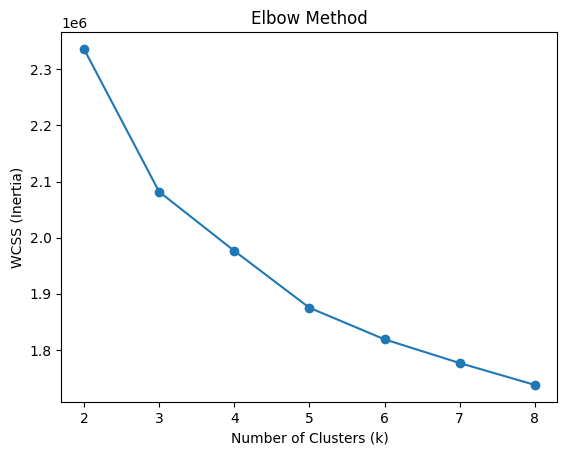

In [13]:

plt.figure()
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.savefig("K Vs WCSS.png")
plt.show()

**Optimal K Value - 6**

**5.2 Silhouette Score VS K**

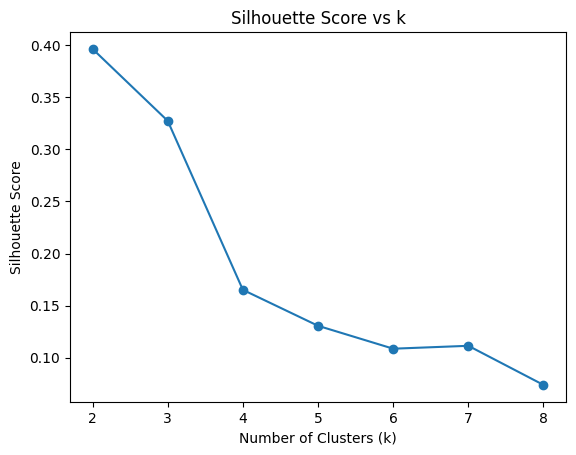

In [14]:
plt.figure()
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.savefig("Silhouette cureve.png")
plt.show()

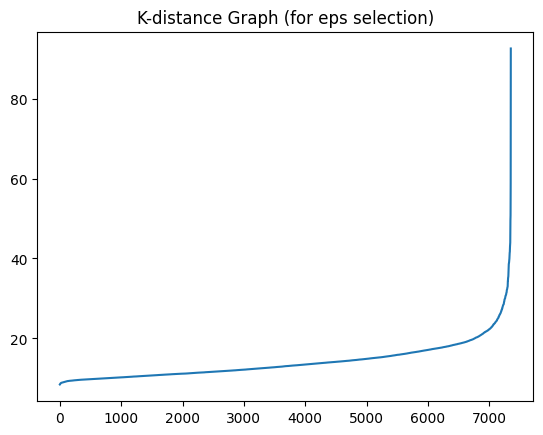

In [15]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title("K-distance Graph (for eps selection)")
plt.show()

**6. DBSCAN Clustering**

Unique clusters: [-1  0]


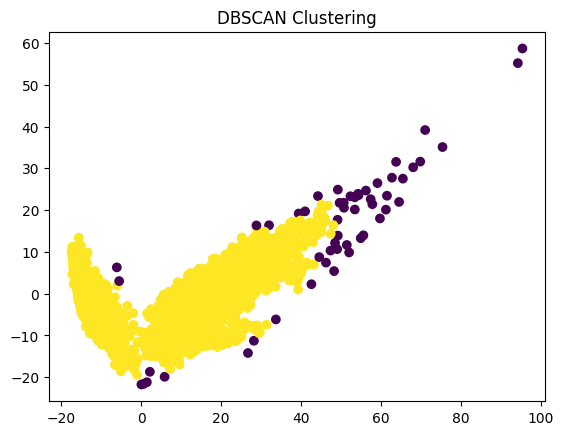

In [16]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# Perform PCA for visualization (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dbscan = DBSCAN(eps=2.5, min_samples=10)
db_labels = dbscan.fit_predict(X_pca) # Apply DBSCAN on PCA-reduced data for consistency with plotting

print("Unique clusters:", np.unique(db_labels))

plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels)
plt.title("DBSCAN Clustering")
plt.savefig("Scatter_dbscan")
plt.show()

**6.2 Refine DBSCAN Clustering**


Based on the K-distance graph, determine an optimal `eps` value, apply DBSCAN to the scaled data with this `eps` and `min_samples=10`, and then visualize the resulting clusters using PCA-reduced data.


**Reasoning**:
We require refining DBSCAN clustering using an optimal `eps` value derived from the K-distance graph. This involves re-applying DBSCAN with the specified parameters to the scaled data and then visualizing the results on the PCA-reduced data.



Unique clusters (refined DBSCAN):
[-1  0]


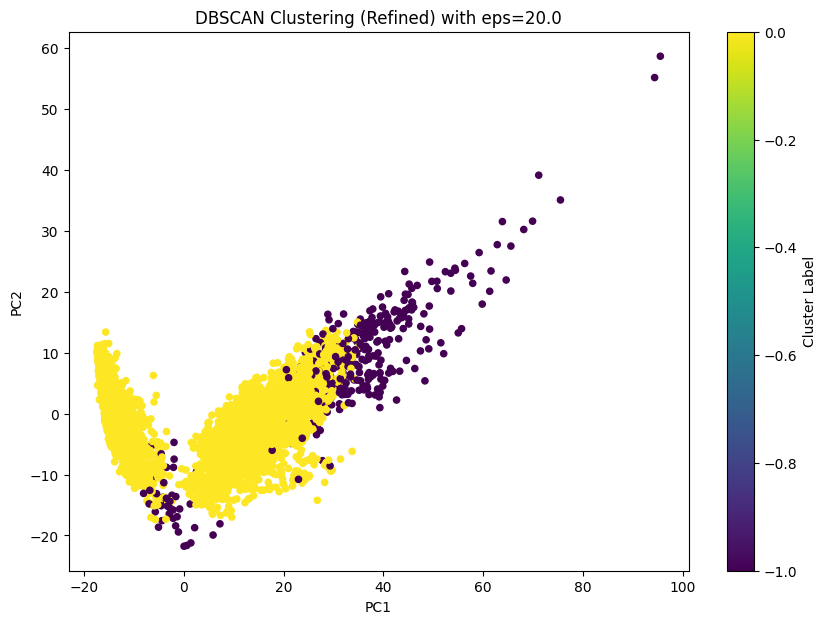

In [17]:
dbscan_refined = DBSCAN(eps=20.0, min_samples=10)
dbscan_labels_refined = dbscan_refined.fit_predict(X_scaled)

print("Unique clusters (refined DBSCAN):")
print(np.unique(dbscan_labels_refined))

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels_refined, cmap='viridis', s=20)
plt.title("DBSCAN Clustering (Refined) with eps=20.0")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster Label')
plt.savefig("scatter_dbscan_refined.png")
plt.show()

**7. Hierarchial - Agglomerative Clustering**


In [18]:
from sklearn.cluster import AgglomerativeClustering

agglomerative = AgglomerativeClustering(n_clusters=6, linkage='ward')
agglom_labels = agglomerative.fit_predict(X_scaled)

print("Agglomerative Clustering labels generated.")

Agglomerative Clustering labels generated.


In [19]:
kmeans_k6 = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels_k6 = kmeans_k6.fit_predict(X_scaled)

print("K-Means (k=6) labels generated.")

K-Means (k=6) labels generated.


**7.1 Dendrograms with Different Linkage Criteria**

To compare the effect of various linkage criteria on hierarchical clustering, we will generate dendrograms using 'single', 'complete', 'average', and 'ward' methods.

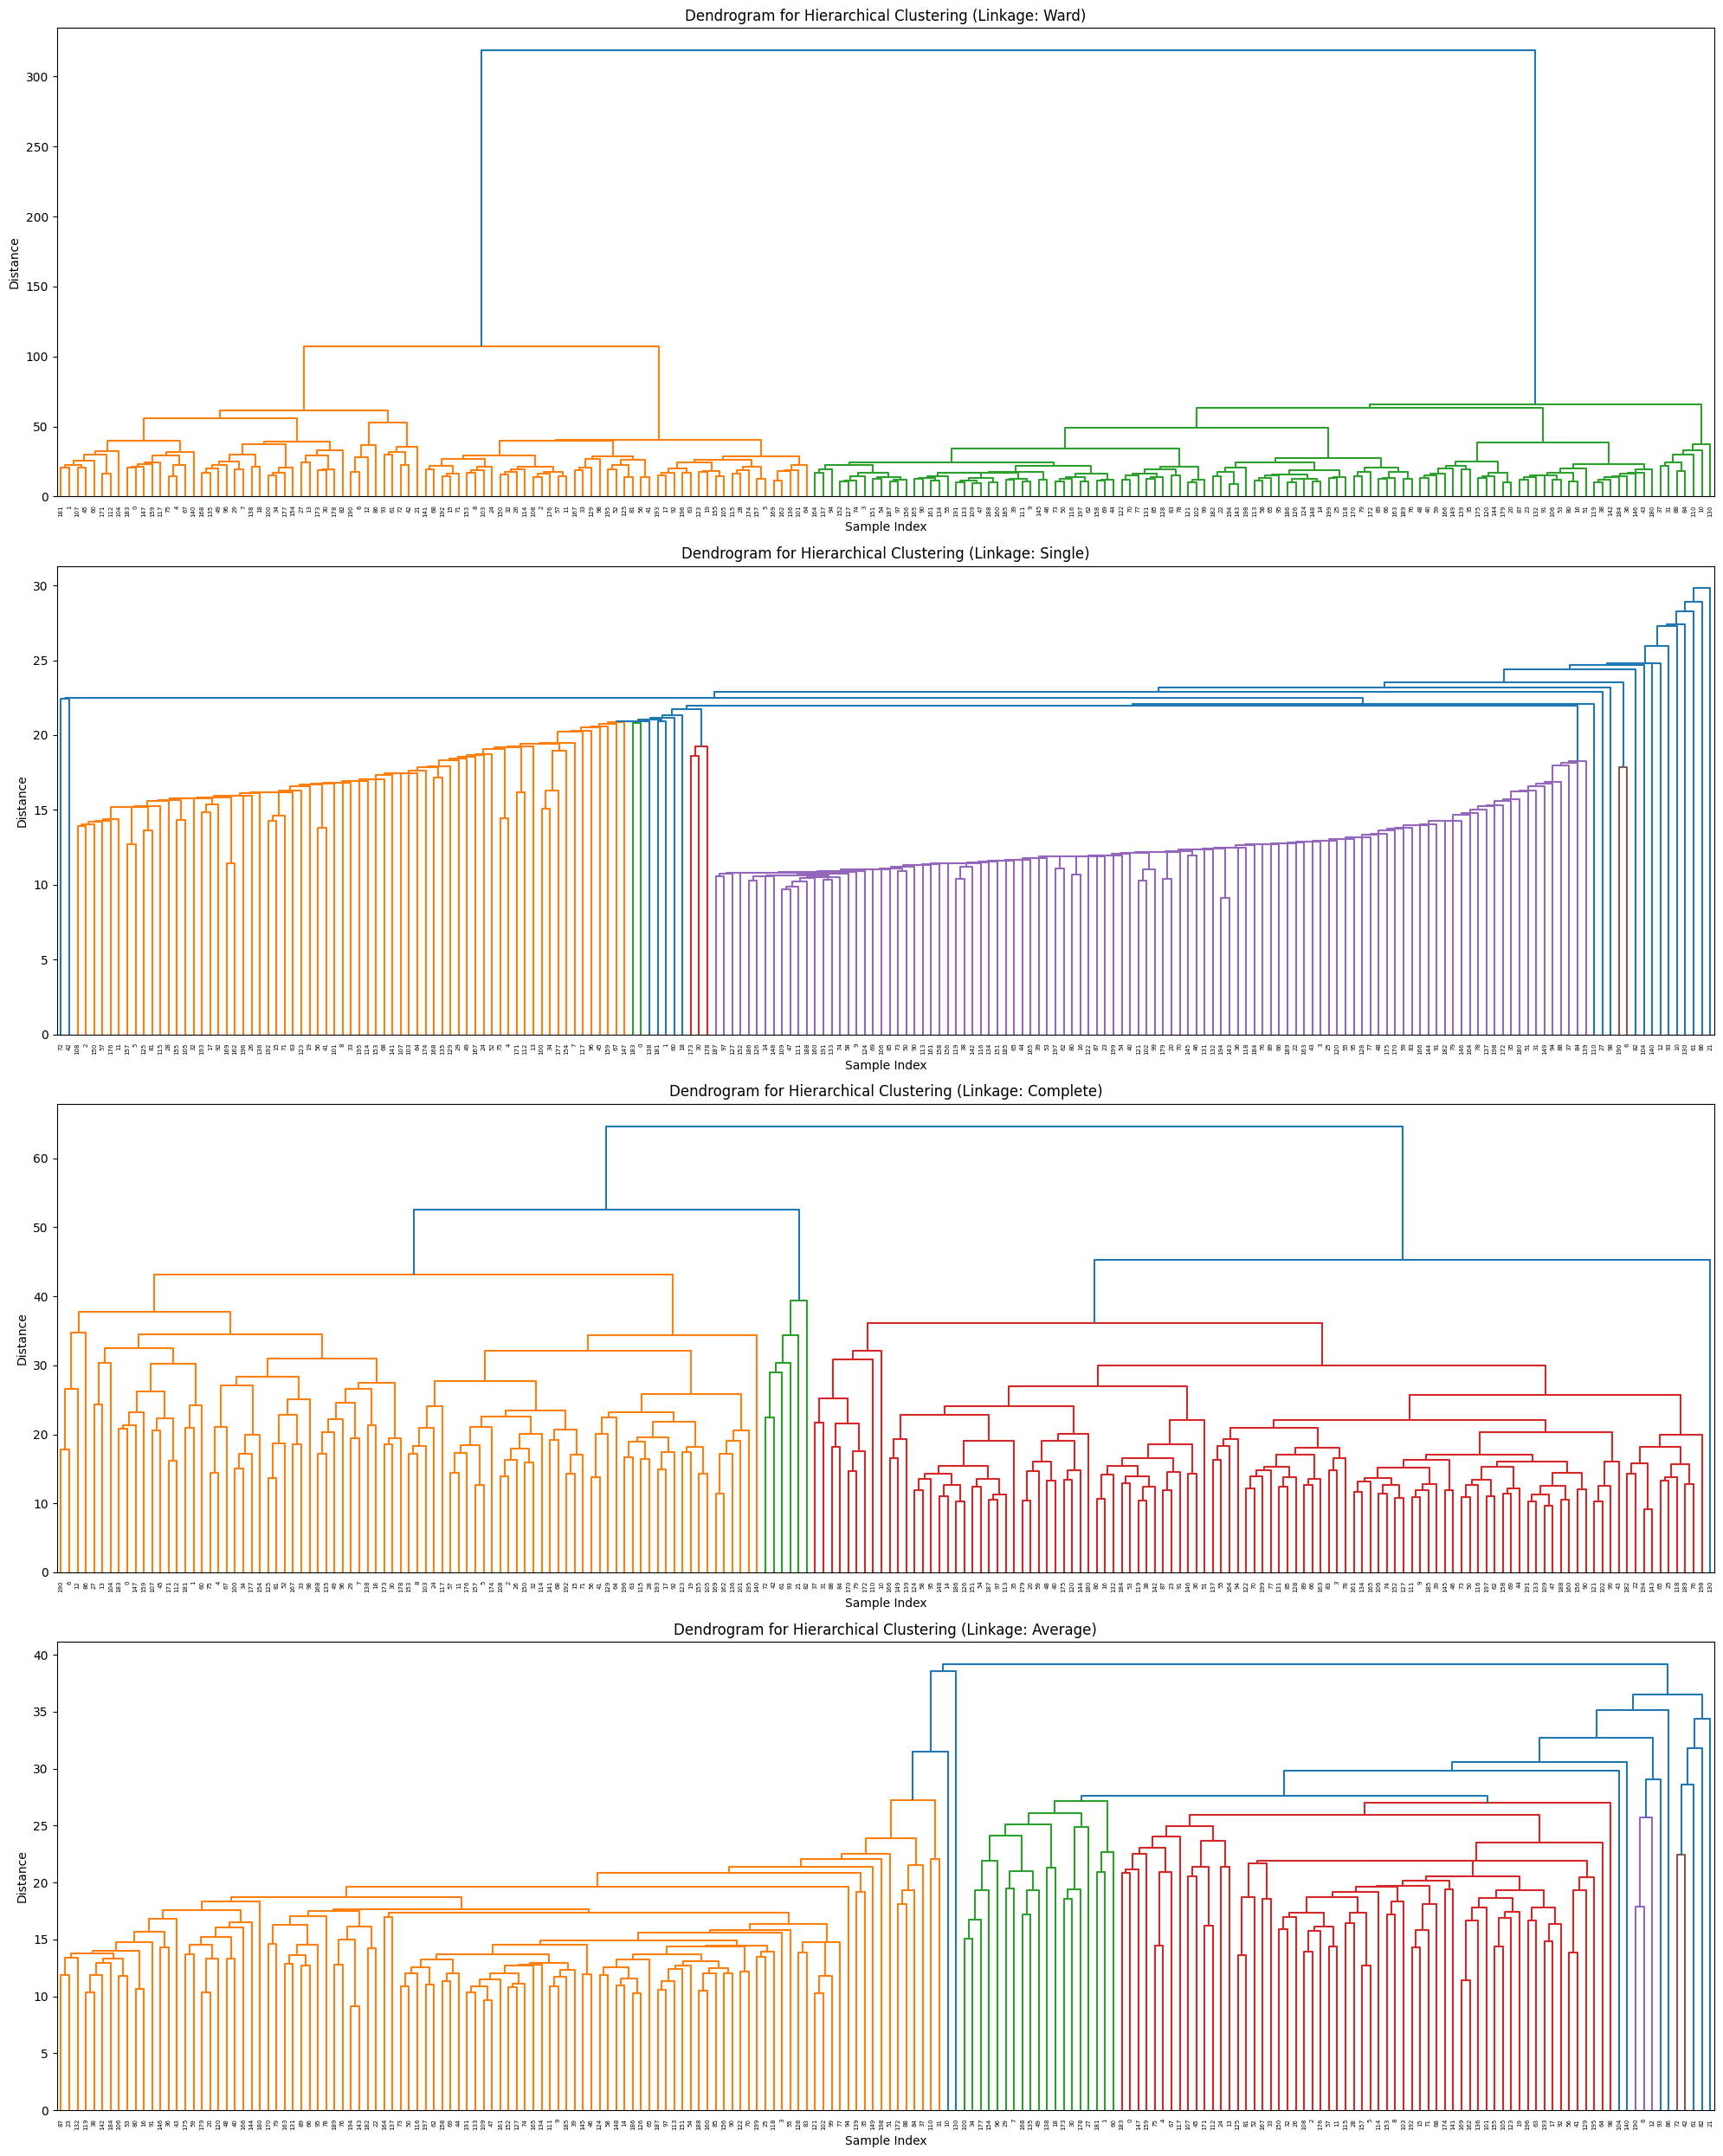

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np


if 'X_sample' not in locals():
    n_samples_dendrogram = 200
    np.random.seed(42) # for reproducibility

    if 'X_scaled' not in locals():
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_train)
    sample_indices = np.random.choice(X_scaled.shape[0], n_samples_dendrogram, replace=False)
    X_sample = X_scaled[sample_indices]
    y_sample = y_train.iloc[sample_indices].values.ravel()


linkage_methods = {
    'Ward': 'ward',
    'Single': 'single',
    'Complete': 'complete',
    'Average': 'average'
}

plt.figure(figsize=(20, 25))

for i, (method_name, method_type) in enumerate(linkage_methods.items()):
    linked_data = linkage(X_sample, method=method_type)

    plt.subplot(len(linkage_methods), 1, i + 1)
    dendrogram(linked_data,
               orientation='top',
               distance_sort='descending',
               show_leaf_counts=True
              )
    plt.title(f'Dendrogram for Hierarchical Clustering (Linkage: {method_name})')
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.savefig(f"Dendrogram_{method_name}.png") # Save each dendrogram

plt.tight_layout()
plt.show()

**7.1 Comparision B/W Agglomerative and K-Means Clustering**

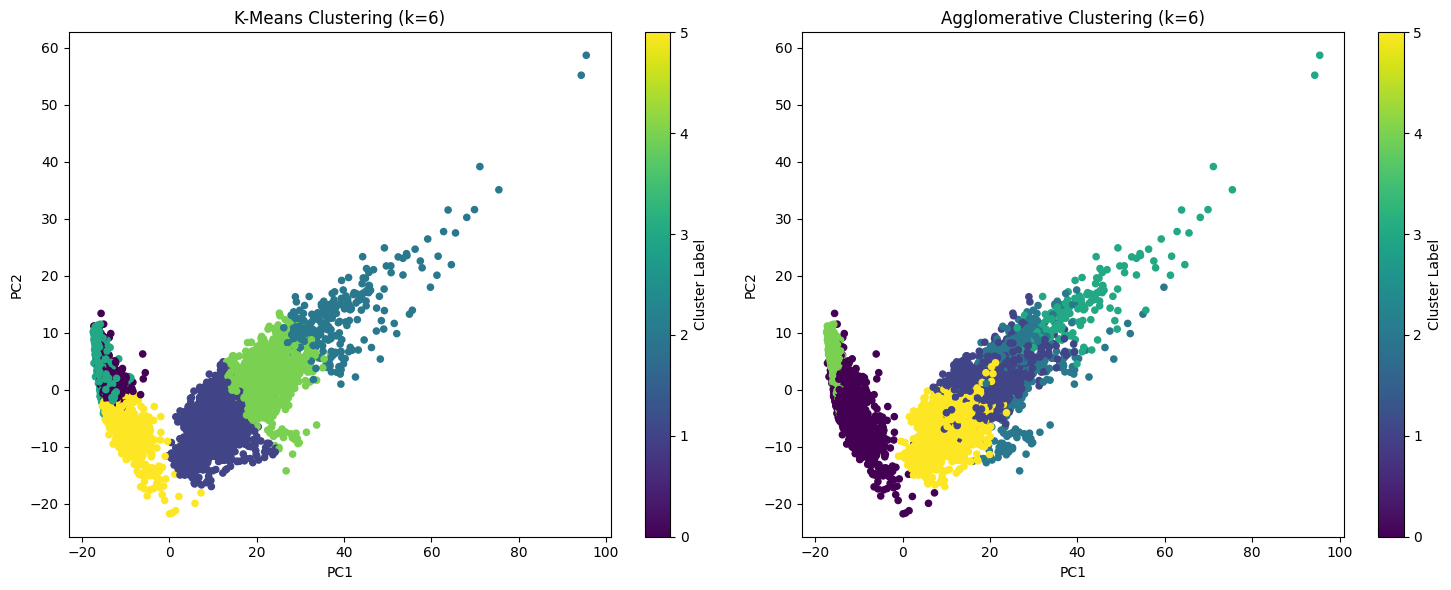

In [21]:
plt.figure(figsize=(15, 6))

# K-Means (k=6) Visualization
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_k6, cmap='viridis', s=20)
plt.title("K-Means Clustering (k=6)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster Label')

# Agglomerative Clustering (k=6) Visualization
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglom_labels, cmap='viridis', s=20)
plt.title("Agglomerative Clustering (k=6)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster Label')

plt.tight_layout()
plt.show()

In [22]:
y_true_flat = y_train.values.ravel()

print("Shape of y_train before flattening:", y_train.shape)
print("Shape of y_true_flat after flattening:", y_true_flat.shape)
print("First 5 elements of y_true_flat:", y_true_flat[:5])

Shape of y_train before flattening: (7352, 1)
Shape of y_true_flat after flattening: (7352,)
First 5 elements of y_true_flat: [5 5 5 5 5]


**8. Evaluation Metrics (NMI and ARI)**

In [23]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

kmeans_ari = adjusted_rand_score(y_true_flat, kmeans_labels_k6)
kmeans_nmi = normalized_mutual_info_score(y_true_flat, kmeans_labels_k6)

print(f"K-Means (k=6) Adjusted Rand Index (ARI): {kmeans_ari:.4f}")
print(f"K-Means (k=6) Normalized Mutual Information (NMI): {kmeans_nmi:.4f}")

K-Means (k=6) Adjusted Rand Index (ARI): 0.4197
K-Means (k=6) Normalized Mutual Information (NMI): 0.5589


In [24]:
dbscan_ari = adjusted_rand_score(y_true_flat, dbscan_labels_refined)
dbscan_nmi = normalized_mutual_info_score(y_true_flat, dbscan_labels_refined)

print(f"DBSCAN (refined) Adjusted Rand Index (ARI): {dbscan_ari:.4f}")
print(f"DBSCAN (refined) Normalized Mutual Information (NMI): {dbscan_nmi:.4f}")

DBSCAN (refined) Adjusted Rand Index (ARI): 0.0079
DBSCAN (refined) Normalized Mutual Information (NMI): 0.0378


In [25]:
agglom_ari = adjusted_rand_score(y_true_flat, agglom_labels)
agglom_nmi = normalized_mutual_info_score(y_true_flat, agglom_labels)

print(f"Agglomerative Clustering Adjusted Rand Index (ARI): {agglom_ari:.4f}")
print(f"Agglomerative Clustering Normalized Mutual Information (NMI): {agglom_nmi:.4f}")

Agglomerative Clustering Adjusted Rand Index (ARI): 0.2794
Agglomerative Clustering Normalized Mutual Information (NMI): 0.4544


In [26]:
dbscan_ari = adjusted_rand_score(y_true_flat, dbscan_labels_refined)
dbscan_nmi = normalized_mutual_info_score(y_true_flat, dbscan_labels_refined)

print(f"DBSCAN (refined) Adjusted Rand Index (ARI): {dbscan_ari:.4f}")
print(f"DBSCAN (refined) Normalized Mutual Information (NMI): {dbscan_nmi:.4f}")

DBSCAN (refined) Adjusted Rand Index (ARI): 0.0079
DBSCAN (refined) Normalized Mutual Information (NMI): 0.0378


/tmp/ipykernel_7779/637469567.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Clustering Method', y='ARI', data=metrics_df, palette='viridis')
/tmp/ipykernel_7779/637469567.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Clustering Method', y='NMI', data=metrics_df, palette='plasma')


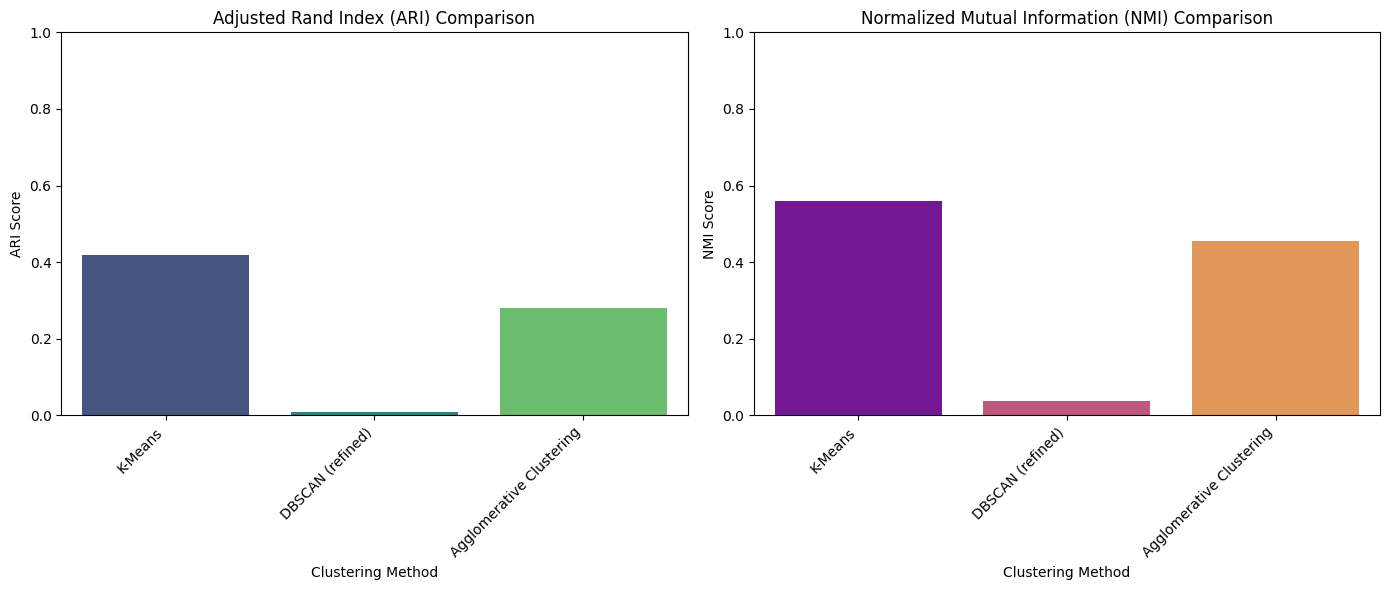

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'kmeans_ari' not in locals():

    kmeans_ari, kmeans_nmi = 0.0, 0.0
    dbscan_ari, dbscan_nmi = 0.0, 0.0
    agglom_ari, agglom_nmi = 0.0, 0.0

results = {
    'Clustering Method': ['K-Means', 'DBSCAN (refined)', 'Agglomerative Clustering'],
    'ARI': [kmeans_ari, dbscan_ari, agglom_ari],
    'NMI': [kmeans_nmi, dbscan_nmi, agglom_nmi]
}
metrics_df = pd.DataFrame(results)

plt.figure(figsize=(14, 6))

# Bar plot for ARI
plt.subplot(1, 2, 1)
sns.barplot(x='Clustering Method', y='ARI', data=metrics_df, palette='viridis')
plt.title('Adjusted Rand Index (ARI) Comparison')
plt.ylabel('ARI Score')
plt.ylim(0, 1) # ARI is between -1 and 1, but typically 0 to 1 for meaningful clusters
plt.xticks(rotation=45, ha='right')

# Bar plot for NMI
plt.subplot(1, 2, 2)
sns.barplot(x='Clustering Method', y='NMI', data=metrics_df, palette='plasma')
plt.title('Normalized Mutual Information (NMI) Comparison')
plt.ylabel('NMI Score')
plt.ylim(0, 1) # NMI is between 0 and 1
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("Bar.png")
plt.show()

**9. Performance Metrics**

In [28]:
import pandas as pd

# Create a dictionary to hold the results
results = {
    'Clustering Method': ['K-Means', 'DBSCAN (refined)', 'Agglomerative Clustering'],
    'ARI': [kmeans_ari, dbscan_ari, agglom_ari],
    'NMI': [kmeans_nmi, dbscan_nmi, agglom_nmi]
}

# Create the DataFrame
metrics_df = pd.DataFrame(results)

# Print the summary table
print("Clustering Performance Metrics:")
print(metrics_df.to_string(index=False))


Clustering Performance Metrics:
       Clustering Method      ARI      NMI
                 K-Means 0.419714 0.558924
        DBSCAN (refined) 0.007865 0.037801
Agglomerative Clustering 0.279386 0.454400
